# Load libraries

In [17]:
# Limitations: 
# Datasets are of differing years. I assume the relative impact of year to be neglible, but this may not be true
# Used Toronto 140 neighbourhoods instead of 158 to include more data
# In cases where multiple neighbourhood 158 points to the same 140, I take a simple mean. 
# This is a simplification, a better approach would be to account for population size first
# Due to the manual process, there may be errors in preprocessing initial datasetes
# Because each voting subdivision may overlap with more than 1 neighbourhood, this is a rough analysis
# K-means on neighbourhood clusters weights variables that belong to a larger group more heavily
# For example, if there were 12 chronic health variables and 2 education variables, the health variables
# Would be weighted more in the final cluster

In [18]:
import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
from matplotlib.patches import Patch, FancyBboxPatch
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.patheffects as path_effects
from matplotlib.patches import Rectangle

import textwrap
import plotly.graph_objects as go
import plotly.express as px
import re

from scipy.stats import pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import kruskal
from sklearn.decomposition import PCA

from statsmodels.stats.multitest import multipletests

pd.set_option("display.float_format", lambda x: f"{x:.6f}")
pd.set_option("display.max_columns", None)

# Correlation

In [19]:
# Load data
df_merge_all = pd.read_excel("final_table.xlsx")

X_master = df_merge_all.drop(
    columns=[
        "NEIGHBOURHOOD_ID",
    ]
)

# Numeric predictors only
X_numeric = X_master.select_dtypes(include=np.number)

# Correlation matrix

corr = X_numeric.corr()
cols = corr.columns


# P-value matrix

pvals = pd.DataFrame(
    np.nan,
    index=cols,
    columns=cols
)

for col1 in cols:
    for col2 in cols:

        if col1 == col2:
            pvals.loc[col1, col2] = 0
            continue

        valid = X_numeric[
            [col1, col2]
        ].dropna()

        if len(valid) >= 3:
            r, p = pearsonr(
                valid[col1],
                valid[col2]
            )

            pvals.loc[col1, col2] = p
            
# Create hover text matrix with same dimensions as correlation matrix
hover_text = np.empty(
    corr.shape,
    dtype=object
)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):

        p = pvals.iloc[i, j]

        # Cleaner p-value formatting
        if p < 0.001:
            p_text = "< 0.001"
        else:
            p_text = f"{p:.3f}"

        hover_text[i, j] = (
            f"<b>{corr.columns[i]}</b><br>"
            f"vs. {corr.columns[j]}<br><br>"
            f"Pearson r: <b>{corr.iloc[i, j]:.2f}</b><br>"
            f"p-value: <b>{p_text}</b>"
        )


# Interactive heatmap

fig = go.Figure(
    data=go.Heatmap(
        z=corr.values,

        x=corr.columns,
        y=corr.index,

        text=hover_text,

        colorscale="RdBu_r",
        zmid=0,
        zmin=-1,
        zmax=1,

        xgap=1,
        ygap=1,

        colorbar=dict(
            title=dict(
                text="Pearson r",
                side="right"
            ),
            thickness=15,
            len=0.65,
            tickvals=[-1, -0.5, 0, 0.5, 1]
        ),

        hovertemplate=(
            "%{text}"
            "<extra></extra>"
        )
    )
)


# Layout

fig.update_layout(

    title=dict(
        text=(
            "Correlation Structure of Toronto Neighbourhood Variables"
            "<br>"
            "<span style='font-size:14px; color:#666666;'>"
            "Pairwise correlations across demographic, social, economic, health, and environmental indicators"
            "</span>"
        ),
        x=0.02,
        xanchor="left",
        font=dict(
            size=22
        )
    ),

    width=1500,
    height=1400,

    paper_bgcolor="white",
    plot_bgcolor="white",

    font=dict(
        family="Arial",
        size=11
    ),

    margin=dict(
        l=280,
        r=100,
        t=100,
        b=280
    )
)


# X axis
fig.update_xaxes(
    tickmode="array",
    tickvals=corr.columns,
    ticktext=corr.columns,
    tickangle=-45,
    side="bottom",
    showgrid=False,
    zeroline=False,
    tickfont=dict(size=8)
)


# Y axis
fig.update_yaxes(
    tickmode="array",
    tickvals=corr.index,
    ticktext=corr.index,
    autorange="reversed",
    showgrid=False,
    zeroline=False,
    tickfont=dict(size=8)
)


fig.show()

fig.write_json(
    "correlation_matrix.json"
)

corr.to_csv('CorrMatrix.csv')

In [20]:
# Function that calculates pairwise correlation, conduct FDR correction, then visualizes the data
def examine_correlations(y):

    results = []

    X = df_merge_all.drop(
        columns=[
            "NEIGHBOURHOOD_ID",
            "NEIGHBOURHOOD",
            y
        ]
    )

    for col in X.columns:

        valid = df_merge_all[[col, y]].dropna()

        r, p = pearsonr(
            valid[col],
            valid[y]
        )

        results.append({
            "Variable": col,
            "Correlation": r,
            "p_value": p,
            "n": len(valid)
        })

    corr_y = pd.DataFrame(results)

    # FDR correction
    reject, p_fdr, _, _ = multipletests(
        corr_y["p_value"],
        alpha=0.05,
        method="fdr_bh"
    )

    corr_y["p_FDR"] = p_fdr
    corr_y["FDR_significant"] = reject

    # Sort strongest correlations first
    corr_y = corr_y.sort_values(
        "Correlation",
        key=abs,
        ascending=False
    )

    # Only correlations surviving FDR
    significant_corr = corr_y[
        corr_y["FDR_significant"]
    ].copy()


    # Plot

    plot_df = significant_corr.sort_values(
        "Correlation"
    ).copy()

    # Optional: clean variable names for display
    plot_df["Label"] = (
        plot_df["Variable"]
    )

    y_label = (
        y
    )

    # Dynamic height depending on number of significant predictors
    fig_height = max(6, len(plot_df) * 0.4)

    fig, ax = plt.subplots(
        figsize=(11, fig_height)
    )

    # Different colors for negative vs positive correlations
    colors = [
        "steelblue" if r < 0 else "indianred"
        for r in plot_df["Correlation"]
    ]

    bars = ax.barh(
        plot_df["Label"],
        plot_df["Correlation"],
        color=colors,
        alpha=0.85
    )

    # Remove extra vertical whitespace above/below bars
    ax.set_ylim(
        -0.5,
        len(plot_df) - 0.5
    )

    # Zero reference line
    ax.axvline(
        x=0,
        color="black",
        linewidth=1,
        linestyle="--"
    )

    # Add correlation value beside each bar
    for bar, r in zip(
        bars,
        plot_df["Correlation"]
    ):

        offset = 0.015 if r >= 0 else -0.015

        ax.text(
            r + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{r:.2f}",
            va="center",
            ha="left" if r >= 0 else "right",
            fontsize=9
        )

    # Make x-axis symmetric around zero
    max_corr = plot_df["Correlation"].abs().max()

    ax.set_xlim(
        -max_corr - 0.10,
        max_corr + 0.10
    )

    # Labels
    ax.set_xlabel(
        f"Pearson correlation with {y_label}",
        fontsize=11
    )

    ax.set_ylabel("")

    title_text = (
        f"Neighbourhood Characteristics Associated with {y_label}\n"
    )

    subtitle_text = (
        "Pearson correlations surviving FDR correction (q < .05)"
    )

    # Wrap long text
    title_wrapped = textwrap.fill(
        title_text,
        width=55
    )

    subtitle_wrapped = textwrap.fill(
        subtitle_text,
        width=70
    )

    # Main title
    ax.set_title(
        title_wrapped,
        fontsize=17,
        fontweight="bold",
        loc="left",
        pad=42
    )

    # Subtitle
    ax.text(
        0,
        1.015,
        subtitle_wrapped,
        transform=ax.transAxes,
        fontsize=10.5,
        color="#666666",
        ha="left",
        va="bottom"
    )

    # Light vertical grid
    ax.grid(
        axis="x",
        linestyle=":",
        alpha=0.4
    )

    ax.set_axisbelow(True)

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Improve tick appearance
    ax.tick_params(
        axis="y",
        length=0,
        labelsize=9,
        pad=12
    )

    ax.tick_params(
        axis="x",
        labelsize=9
    )

    plt.tight_layout()
    plt.subplots_adjust(left=0.35)
    plt.show()

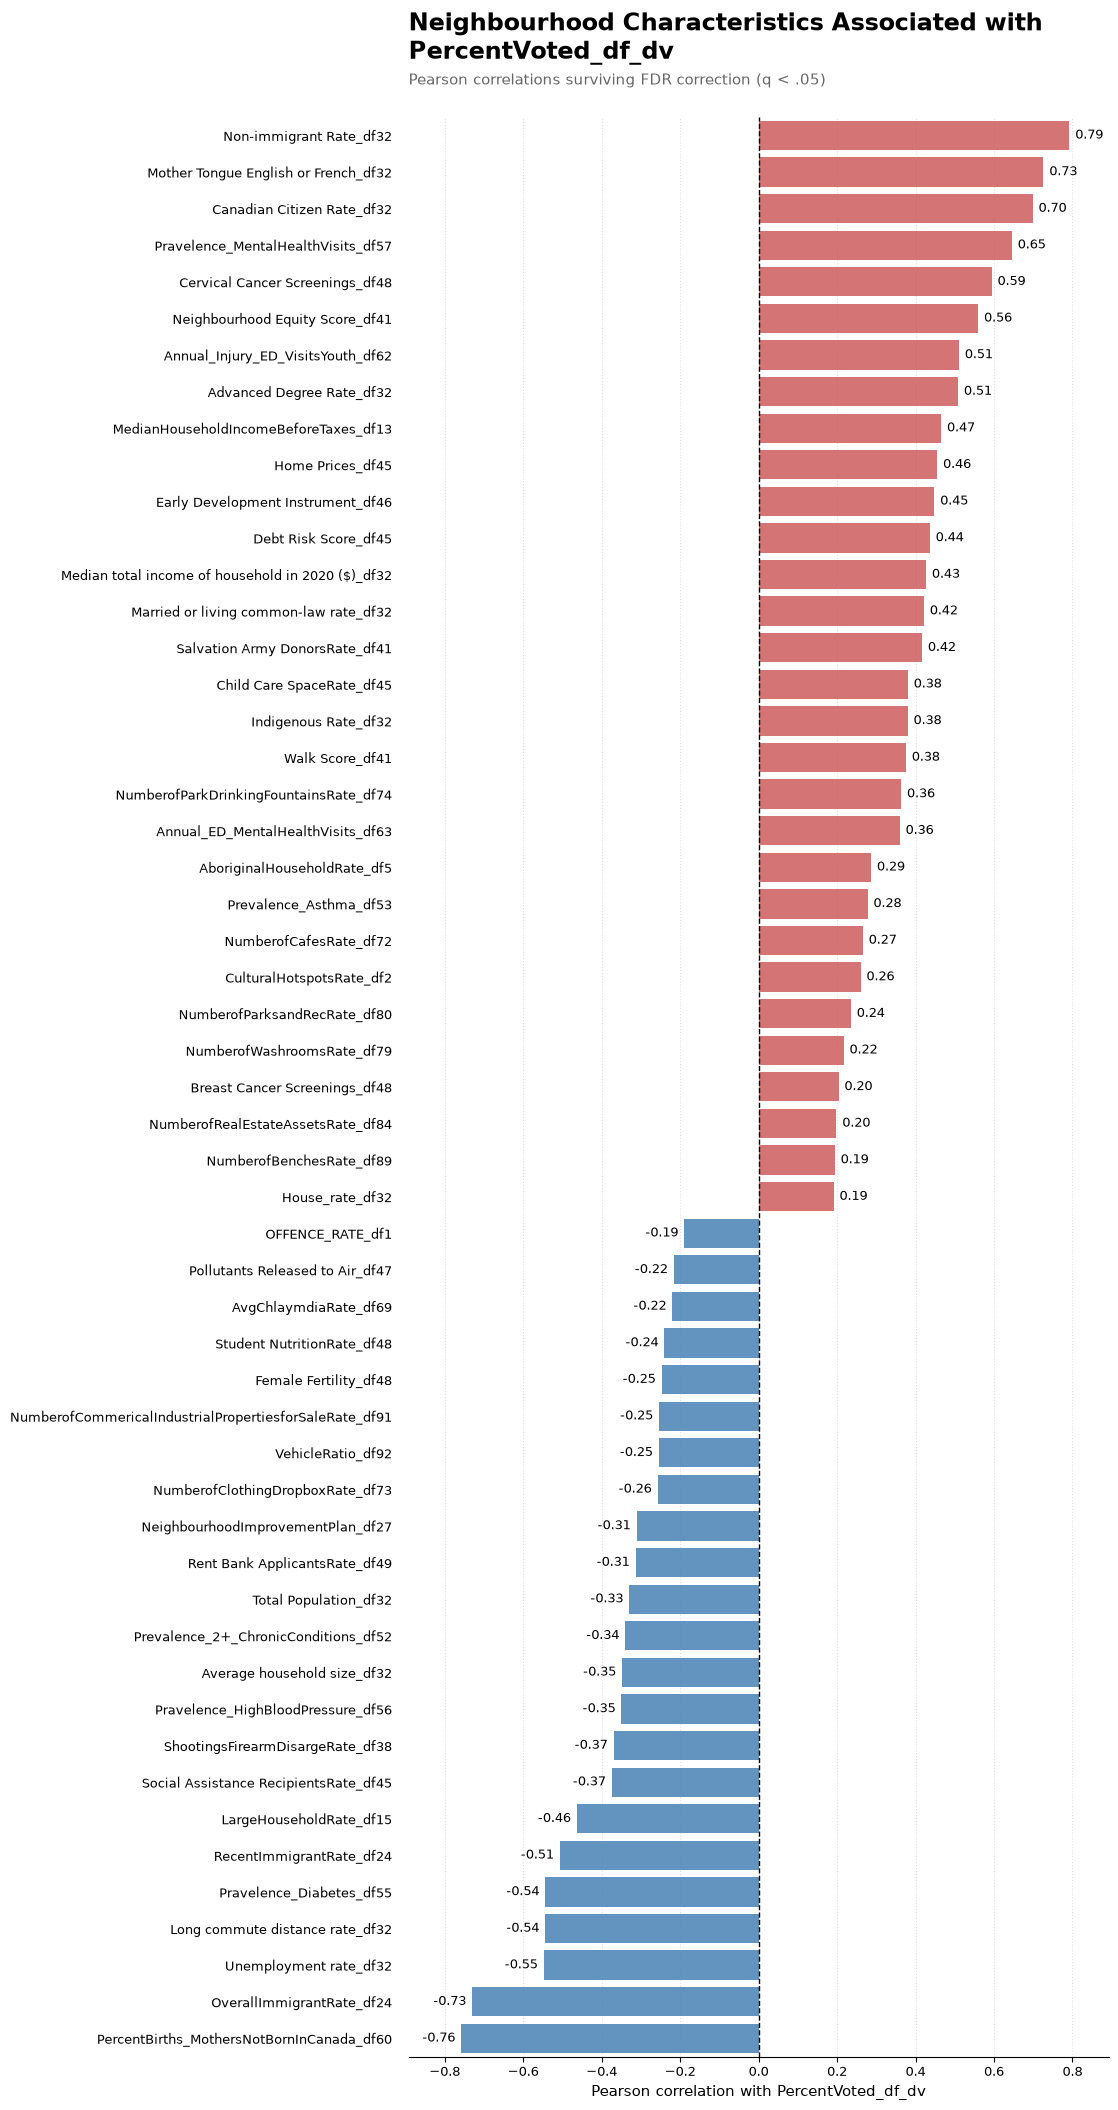

In [21]:
examine_correlations("PercentVoted_df_dv")

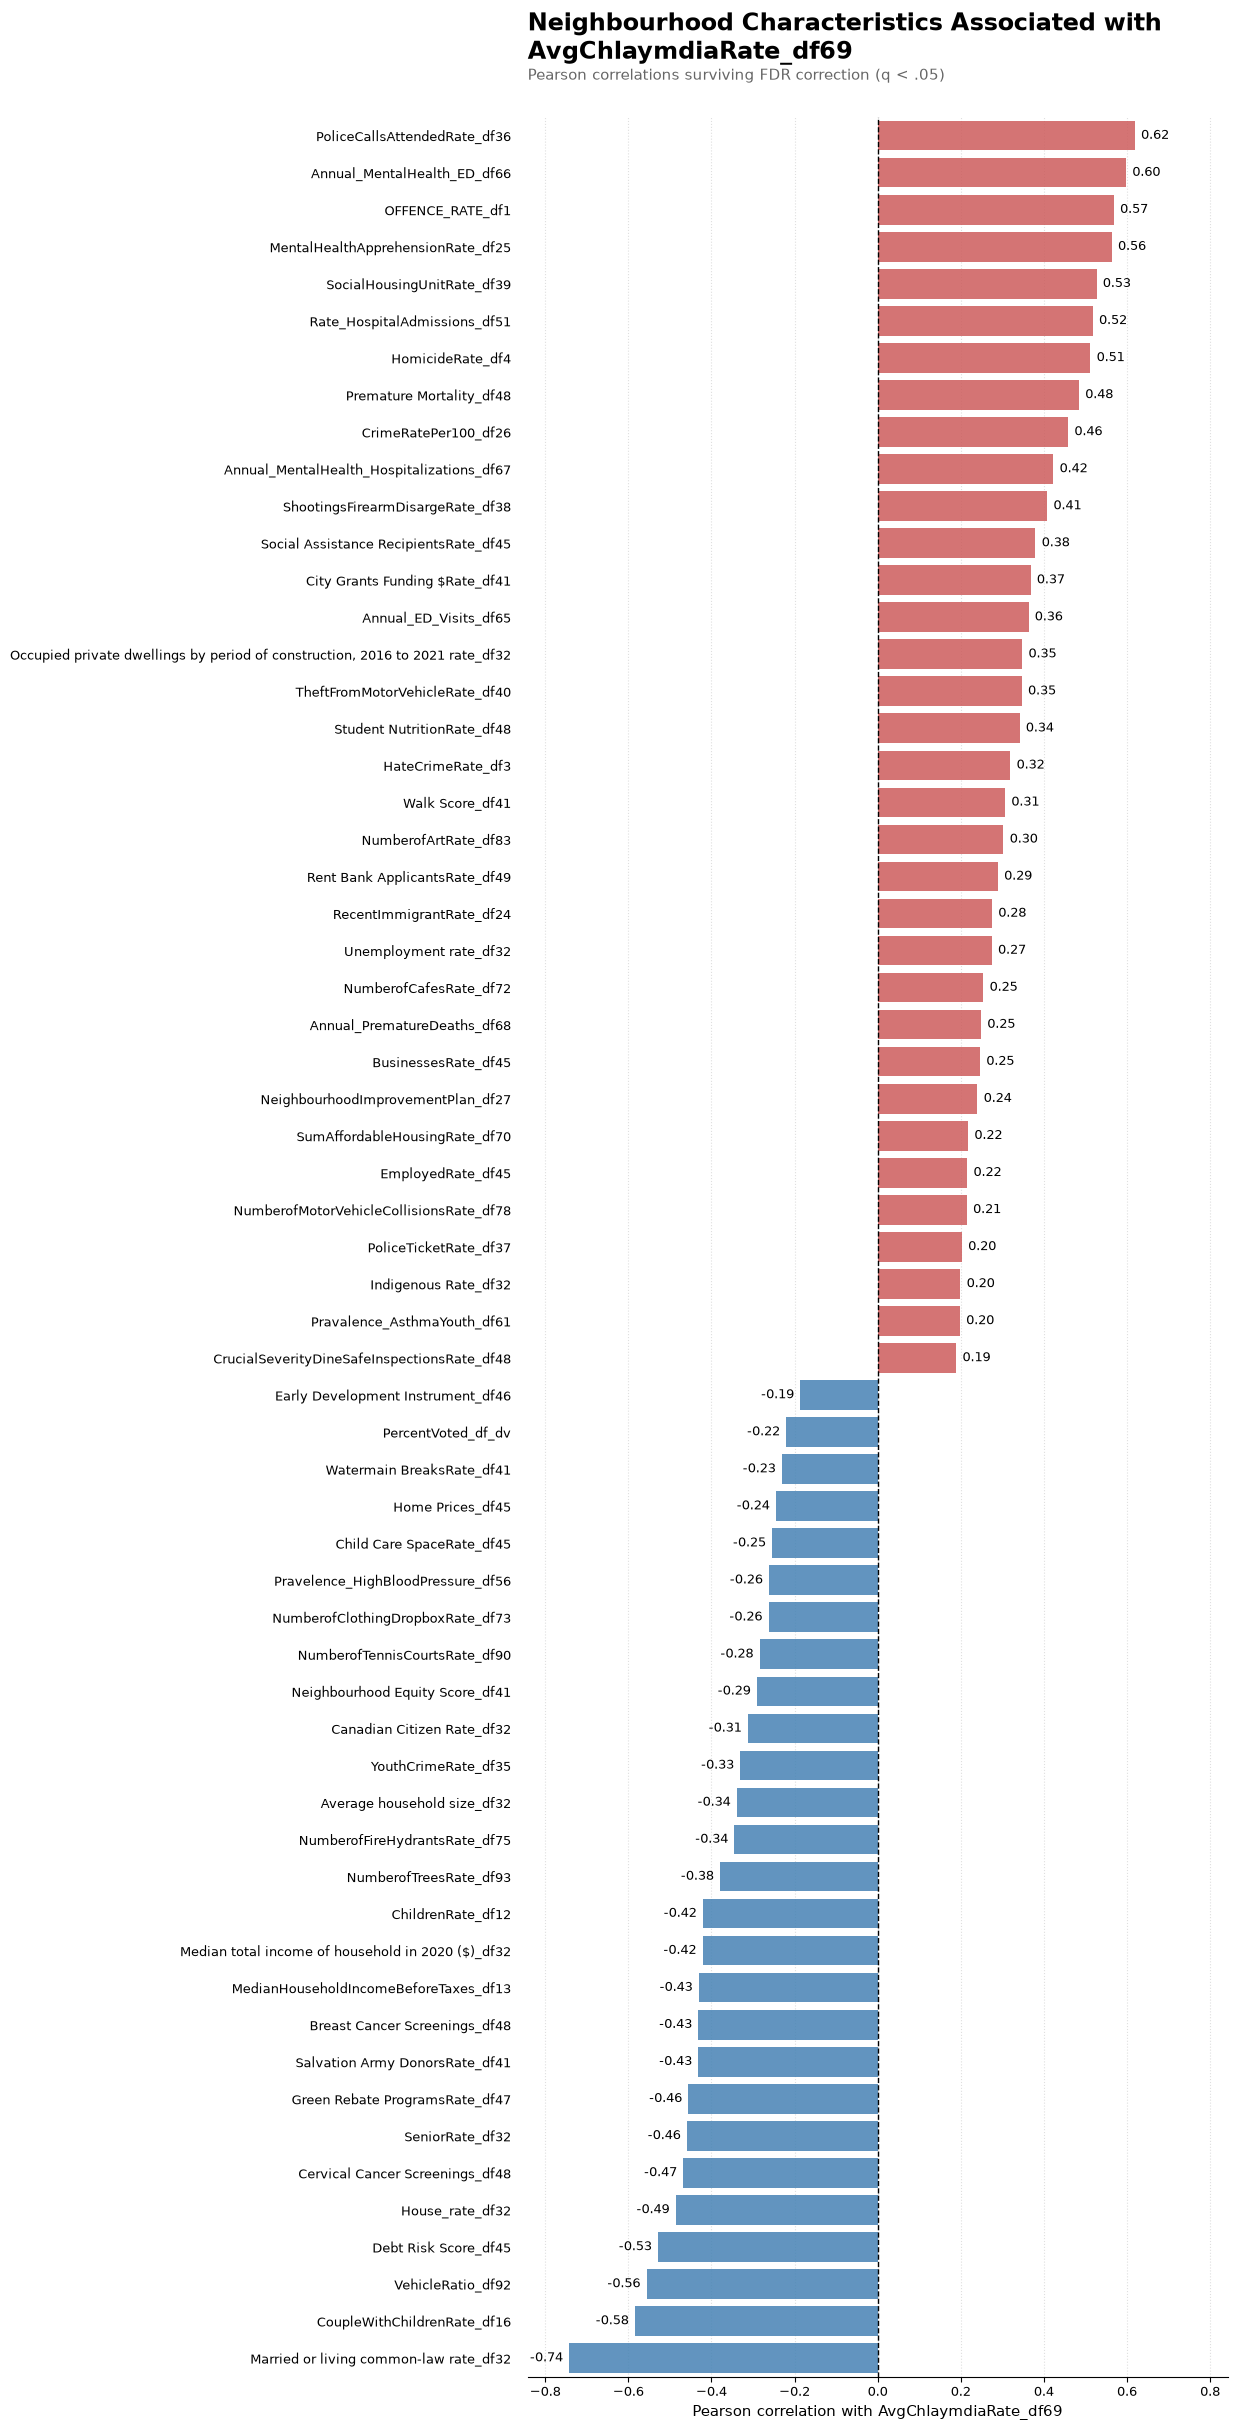

In [22]:
examine_correlations("AvgChlaymdiaRate_df69")

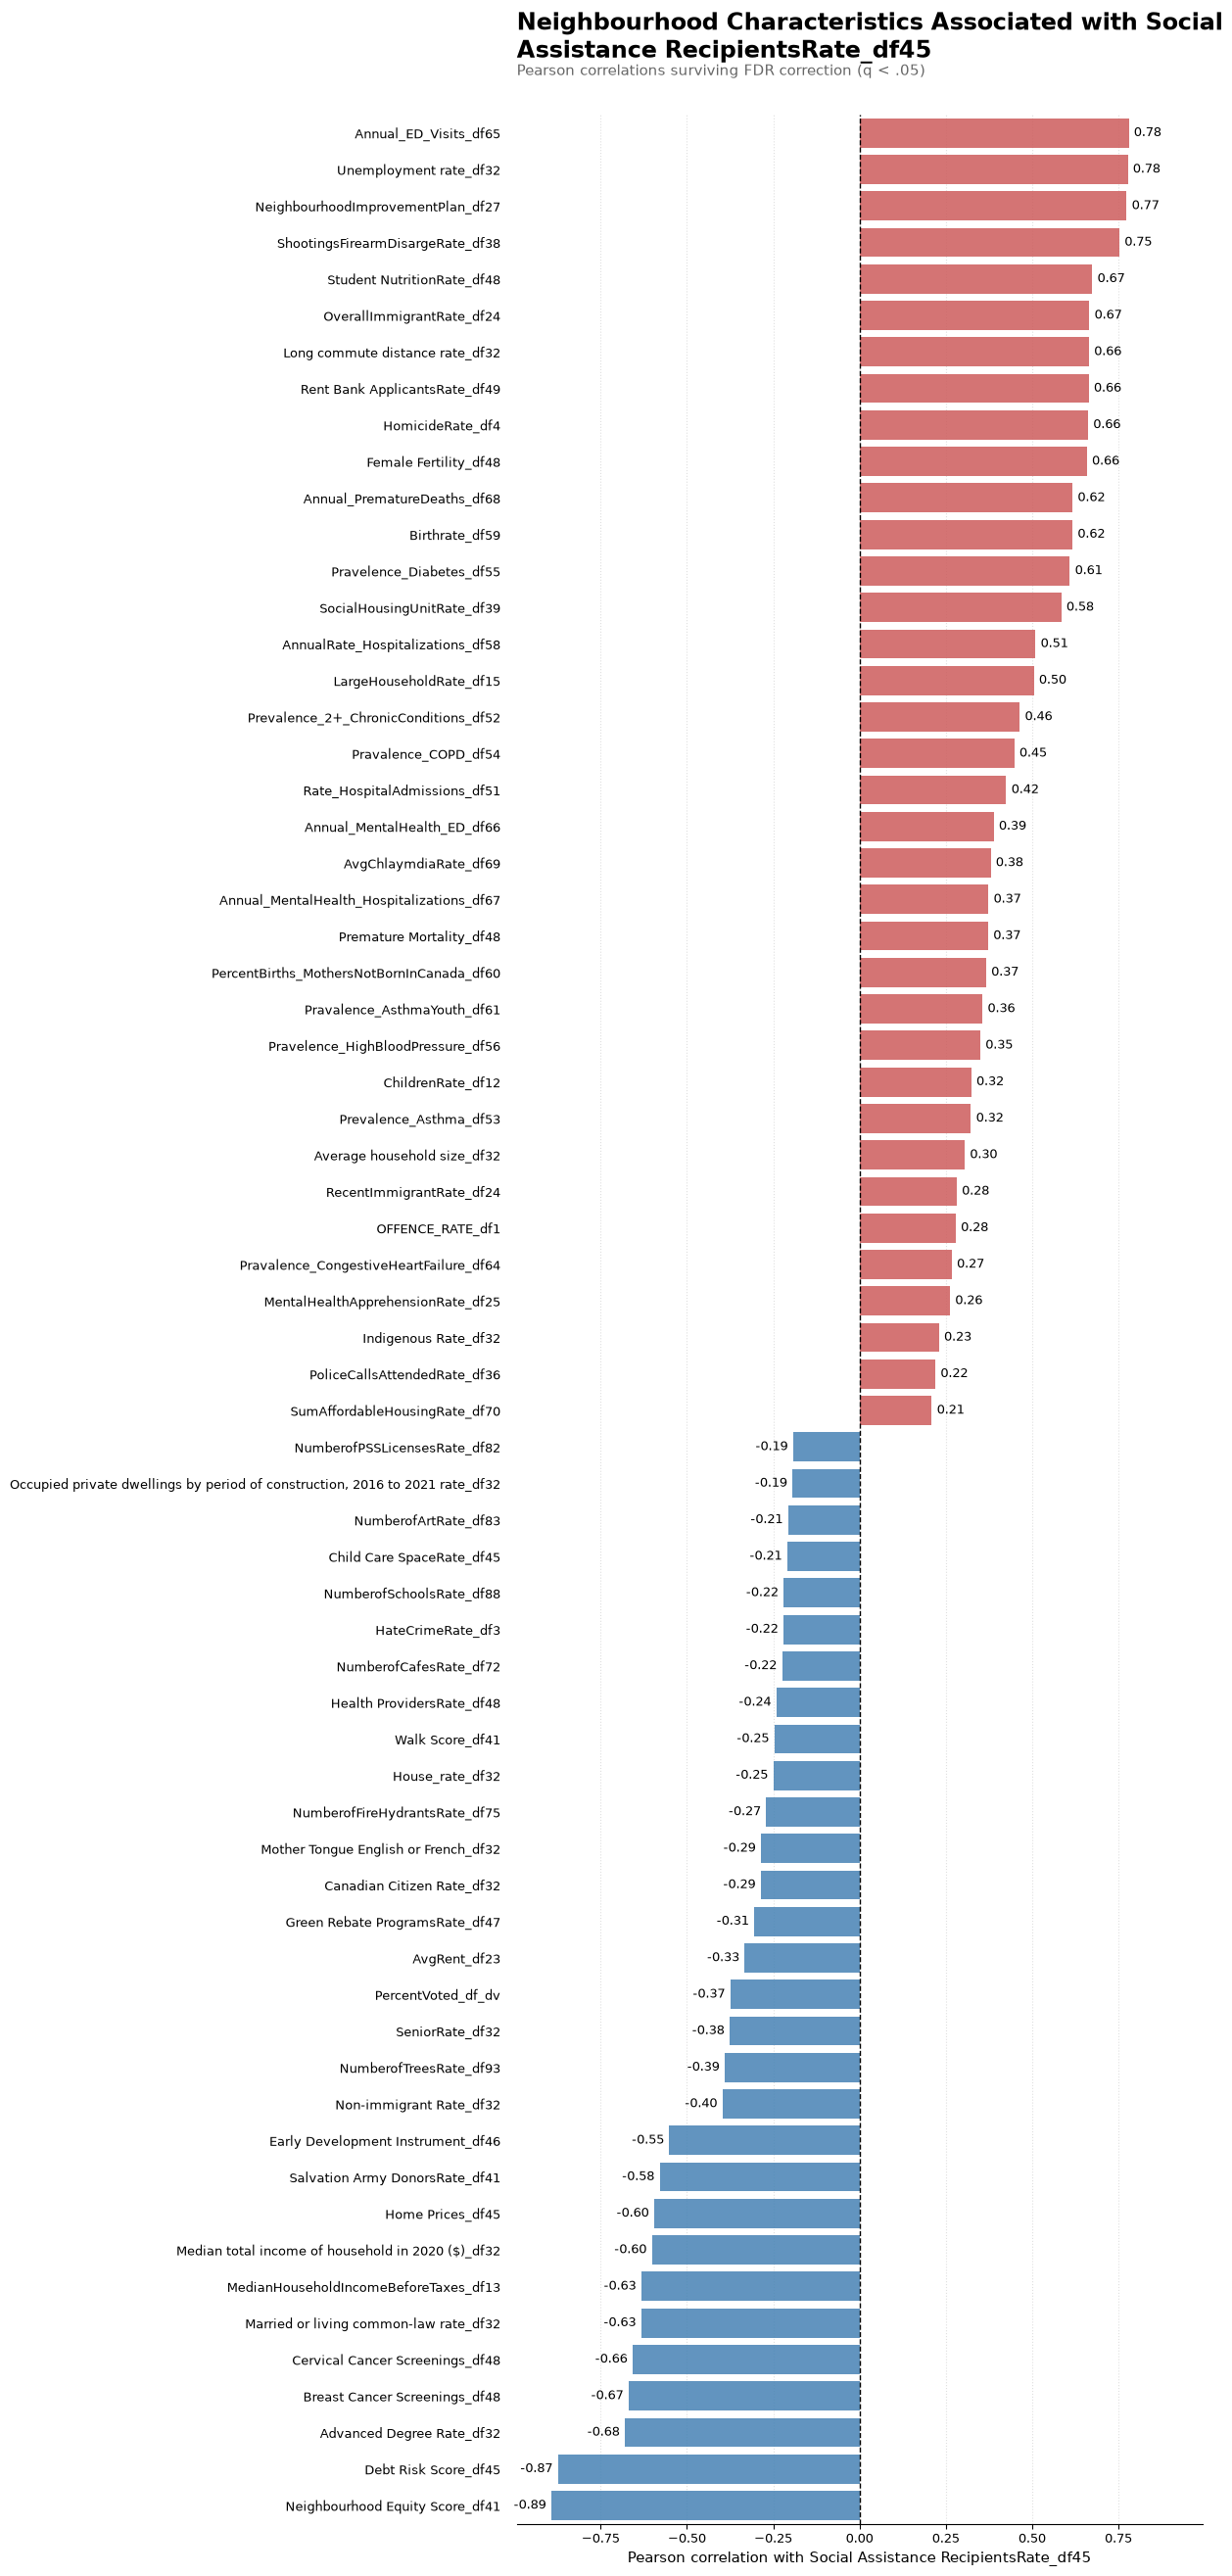

In [23]:
examine_correlations("Social Assistance RecipientsRate_df45")

# Dendrogram

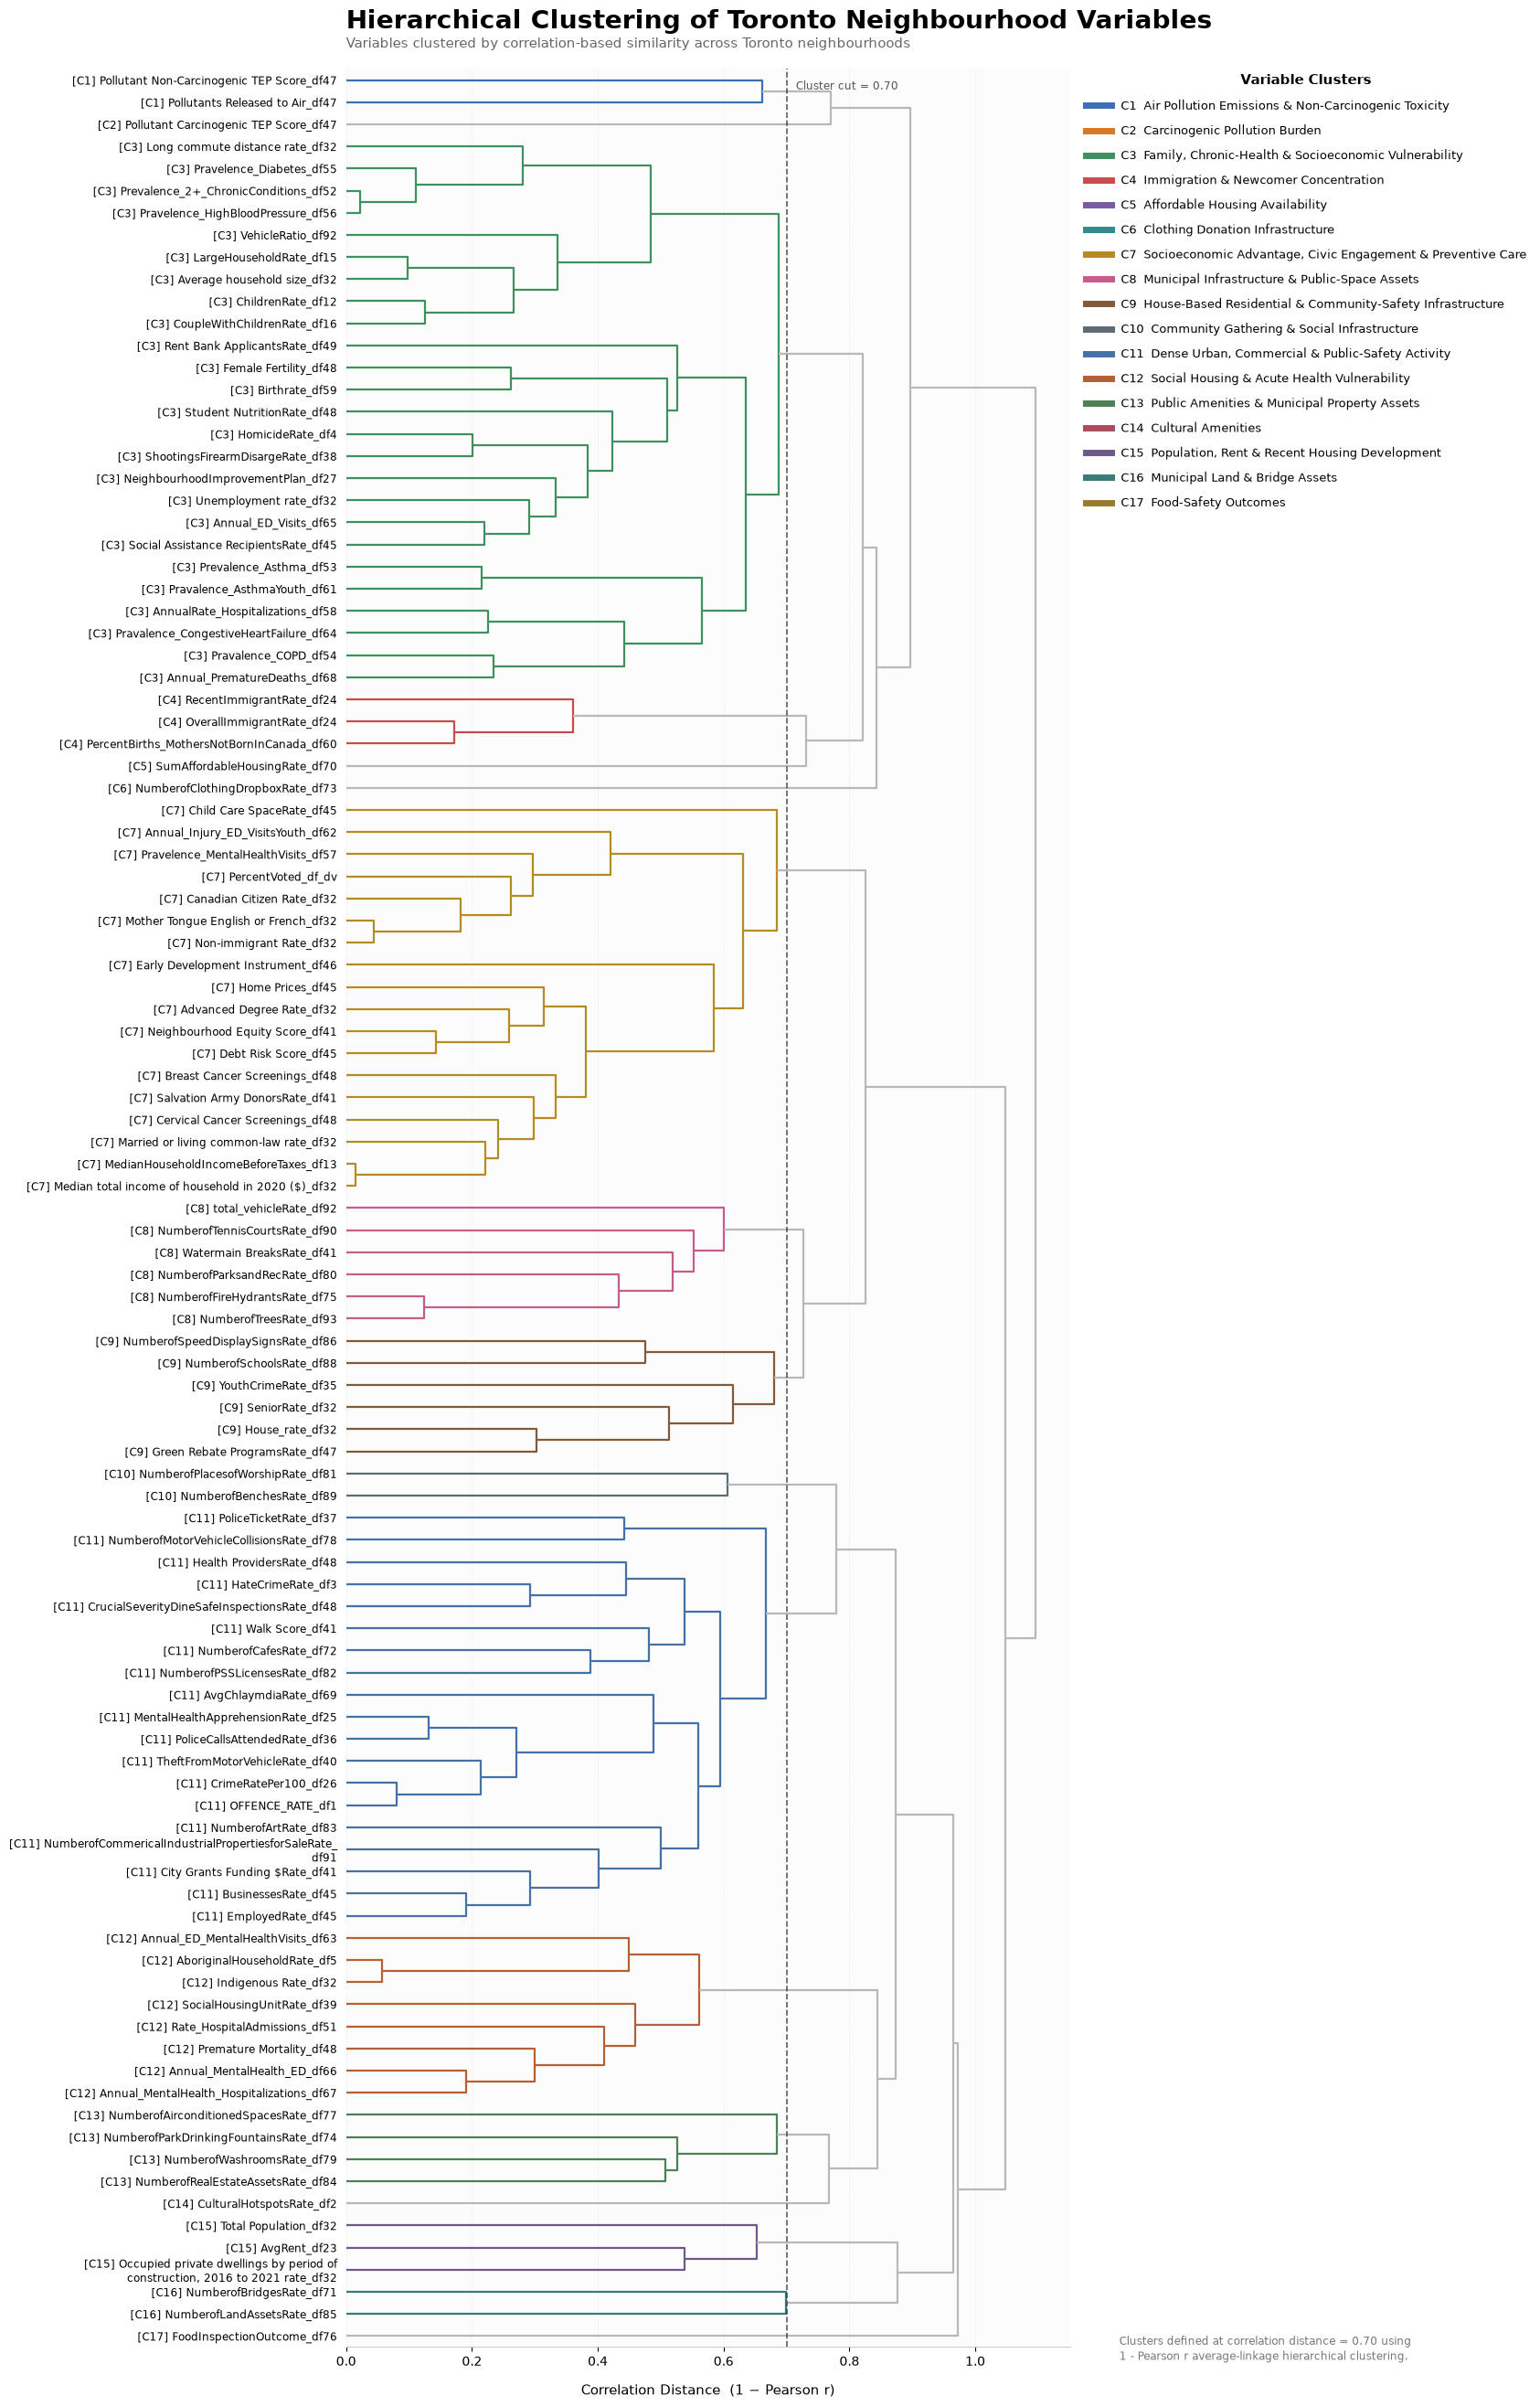

In [24]:
# 1. Prepare variables

X = df_merge_all.drop(
    columns=[
        "NEIGHBOURHOOD_ID",
        "NEIGHBOURHOOD"
    ]
)

X = X.select_dtypes(
    include=np.number
)


# 2. Correlation clustering

corr = X.corr()

distance = 1 - corr

distance_condensed = squareform(
    distance.values,
    checks=False
)

Z = linkage(
    distance_condensed,
    method="average"
)

threshold = 0.7


# 3. Flat cluster assignments

variable_cluster_labels = fcluster(
    Z,
    t=threshold,
    criterion="distance"
)

variable_cluster_map = dict(
    zip(
        X.columns,
        variable_cluster_labels
    )
)

# C1 -> C2 -> C3 -> ... from top to bottom

Z_sorted = Z.copy()

n_variables = len(X.columns)

# For each node, store the cluster IDs contained beneath it
node_cluster_sets = {
    i: {variable_cluster_labels[i]}
    for i in range(n_variables)
}

for i in range(len(Z_sorted)):

    left = int(Z_sorted[i, 0])
    right = int(Z_sorted[i, 1])

    left_clusters = node_cluster_sets[left]
    right_clusters = node_cluster_sets[right]

    # Put smaller-numbered cluster first
    if min(left_clusters) > min(right_clusters):

        Z_sorted[i, 0], Z_sorted[i, 1] = (
            Z_sorted[i, 1],
            Z_sorted[i, 0]
        )

        left, right = right, left
        left_clusters, right_clusters = (
            right_clusters,
            left_clusters
        )

    node_id = n_variables + i

    node_cluster_sets[node_id] = (
        left_clusters | right_clusters
    )

# 4. Descriptive cluster names
# The variables were fed into ChatGPT and it provided summary themes for each cluster
cluster_names = {
    1: "Air Pollution Emissions & Non-Carcinogenic Toxicity",
    2: "Carcinogenic Pollution Burden",
    3: "Family, Chronic-Health & Socioeconomic Vulnerability",
    4: "Immigration & Newcomer Concentration",
    5: "Affordable Housing Availability",
    6: "Clothing Donation Infrastructure",
    7: "Socioeconomic Advantage, Civic Engagement & Preventive Care",
    8: "Municipal Infrastructure & Public-Space Assets",
    9: "House-Based Residential & Community-Safety Infrastructure",
    10: "Community Gathering & Social Infrastructure",
    11: "Dense Urban, Commercial & Public-Safety Activity",
    12: "Social Housing & Acute Health Vulnerability",
    13: "Public Amenities & Municipal Property Assets",
    14: "Cultural Amenities",
    15: "Population, Rent & Recent Housing Development",
    16: "Municipal Land & Bridge Assets",
    17: "Food-Safety Outcomes"
}


# 5. Give every cluster a distinct color

unique_clusters = sorted(
    np.unique(variable_cluster_labels)
)

cmap = plt.get_cmap(
    "tab20"
)

# Consistent cluster colors

cluster_palette = [
    "#3B6FB6",  # C1  blue
    "#D97824",  # C2  orange
    "#3F8F5F",  # C3  green
    "#C94C4C",  # C4  red
    "#7A5AA6",  # C5  purple
    "#2F8C8C",  # C6  teal
    "#B68B20",  # C7  mustard
    "#C75B8B",  # C8  pink
    "#805A3B",  # C9  brown
    "#5F6B73",  # C10 slate
    "#4472A8",  # C11 steel blue
    "#B45F34",  # C12 burnt orange
    "#4E8055",  # C13 forest green
    "#A94E5D",  # C14 muted crimson
    "#6E5A8A",  # C15 violet
    "#377C78",  # C16 dark teal
    "#9A7A2E",  # C17 ochre
    "#A8577A",  # C18 berry
    "#6D665C"   # C19 warm grey
]

cluster_colors = {
    cluster: cluster_palette[i]
    for i, cluster in enumerate(unique_clusters)
}


# 6. Determine which cluster each dendrogram node
#    belongs to

n_variables = len(X.columns)

# Leaf node -> cluster
node_clusters = {
    i: {variable_cluster_labels[i]}
    for i in range(n_variables)
}

# Build cluster membership for every internal node
for i, row in enumerate(Z):

    left = int(row[0])
    right = int(row[1])

    node_id = n_variables + i

    node_clusters[node_id] = (
        node_clusters[left]
        | node_clusters[right]
    )


# 7. Custom branch coloring

def link_color_func(node_id):

    groups = node_clusters[
        int(node_id)
    ]

    # Branch contains leaves from one flat cluster
    if len(groups) == 1:

        cluster = next(
            iter(groups)
        )

        return cluster_colors[
            cluster
        ]

    # Branch combines multiple clusters
    return "#B8B8B8"


# 8. Variable labels

# Wrap long variable names
variable_wrap_width = 50

labels_with_cluster = [
    (
        f"[C{variable_cluster_map[col]}] "
        + textwrap.fill(
            col,
            width=variable_wrap_width,
            subsequent_indent="     "
        )
    )
    for col in X.columns
]


# 9. Plot

fig, ax = plt.subplots(
    figsize=(18, 28)
)

fig.patch.set_facecolor(
    "white"
)

ax.set_facecolor(
    "#FCFCFC"
)


dendrogram(
    Z_sorted,
    labels=labels_with_cluster,
    orientation="right",
    leaf_font_size=8.5,
    link_color_func=link_color_func,
    above_threshold_color="#B8B8B8",
    ax=ax
)

# Make all dendrogram branches visually consistent
for collection in ax.collections:
    collection.set_linewidth(1.6)
    collection.set_alpha(1.0)

# invert y-axis

ax.invert_yaxis()


# Threshold line

ax.axvline(
    threshold,
    color="#333333",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8
)

ax.text(
    threshold + 0.015,
    0.995,
    "Cluster cut = 0.70",
    transform=ax.get_xaxis_transform(),
    fontsize=8.5,
    color="#555555",
    ha="left",
    va="top"
)

# Title

ax.set_title(
    "Hierarchical Clustering of Toronto Neighbourhood Variables",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=32
)

ax.text(
    0,
    1.008,
    "Variables clustered by correlation-based similarity across Toronto neighbourhoods",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666",
    va="bottom"
)


# Axis label

ax.set_xlabel(
    "Correlation Distance  (1 − Pearson r)",
    fontsize=11,
    labelpad=12
)

ax.set_ylabel("")


# Grid

ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
    alpha=0.25
)


# Remove unnecessary borders

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color(
    "#CCCCCC"
)


# 10. Custom cluster legend

legend_handles = []

# Wrap long cluster names in legend
# Wrap long cluster names in legend
legend_wrap_width = 60

for cluster in unique_clusters:

    prefix = f"C{cluster}  "

    wrapped_name = textwrap.fill(
        cluster_names[cluster],
        width=legend_wrap_width,
        subsequent_indent=" " * len(prefix)
    )

    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=cluster_colors[cluster],
            lw=5,
            label=prefix + wrapped_name
        )
    )


legend = ax.legend(
    handles=legend_handles,
    title="Variable Clusters",
    loc="upper left",
    bbox_to_anchor=(1.015, 1.0),
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    labelspacing=1.05,
    handlelength=2.3,
    borderaxespad=0
)

legend.get_title().set_fontweight(
    "bold"
)


# 11. Small methodological note

fig.text(
    0.79,
    0.055,
    "Clusters defined at correlation distance = 0.70 using\n"
    "1 - Pearson r average-linkage hierarchical clustering.",
    fontsize=8.5,
    color="#777777",
    ha="left",
    linespacing=1.4
)


# Leave room for legend
plt.subplots_adjust(
    left=0.32,
    right=0.76,
    top=0.95,
    bottom=0.06
)

plt.show()

In [25]:
variable_clusters = pd.DataFrame({
    "Variable": X.columns,
    "Cluster": variable_cluster_labels
})

variable_clusters = variable_clusters.sort_values(
    ["Cluster", "Variable"]
).reset_index(drop=True)

variables_by_cluster = (
    variable_clusters
    .groupby("Cluster")["Variable"]
    .apply(list)
    .to_dict()
)

variables_by_cluster

{1: ['Pollutant Non-Carcinogenic TEP Score_df47',
  'Pollutants Released to Air_df47'],
 2: ['Pollutant Carcinogenic TEP Score_df47'],
 3: ['AnnualRate_Hospitalizations_df58',
  'Annual_ED_Visits_df65',
  'Annual_PrematureDeaths_df68',
  'Average household size_df32',
  'Birthrate_df59',
  'ChildrenRate_df12',
  'CoupleWithChildrenRate_df16',
  'Female Fertility_df48',
  'HomicideRate_df4',
  'LargeHouseholdRate_df15',
  'Long commute distance rate_df32',
  'NeighbourhoodImprovementPlan_df27',
  'Pravalence_AsthmaYouth_df61',
  'Pravalence_COPD_df54',
  'Pravalence_CongestiveHeartFailure_df64',
  'Pravelence_Diabetes_df55',
  'Pravelence_HighBloodPressure_df56',
  'Prevalence_2+_ChronicConditions_df52',
  'Prevalence_Asthma_df53',
  'Rent Bank ApplicantsRate_df49',
  'ShootingsFirearmDisargeRate_df38',
  'Social Assistance RecipientsRate_df45',
  'Student NutritionRate_df48',
  'Unemployment rate_df32',
  'VehicleRatio_df92'],
 4: ['OverallImmigrantRate_df24',
  'PercentBirths_MothersN

# Clustering Neighbourhoods

In [26]:
# Keep neighbourhood information separately
neighbourhood_info = df_merge_all[
    [
        "NEIGHBOURHOOD_ID",
        "NEIGHBOURHOOD"
    ]
].copy()


# Use all numeric variables for clustering
# Only exclude neighbourhood identifiers/names
X_neighbourhoods = (
    df_merge_all
    .drop(
        columns=[
            "NEIGHBOURHOOD_ID",
            "NEIGHBOURHOOD"
        ]
    )
    .select_dtypes(include="number")
)

imputer = SimpleImputer(
    strategy="median"
)

X_imputed = imputer.fit_transform(X_neighbourhoods)

scaler = StandardScaler()

# z-score variables
X_scaled = scaler.fit_transform(
    X_imputed
)

# To select K
silhouette_results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = model.fit_predict(
        X_scaled
    )
    
    # Silhouette score measures: are neighbourhoods closer to their own cluster than
    # to neighbouring clusters?
    silhouette_results.append({
        "k": k,
        "Silhouette": silhouette_score(
            X_scaled,
            labels
        )
    })


silhouette_df = pd.DataFrame(
    silhouette_results
)

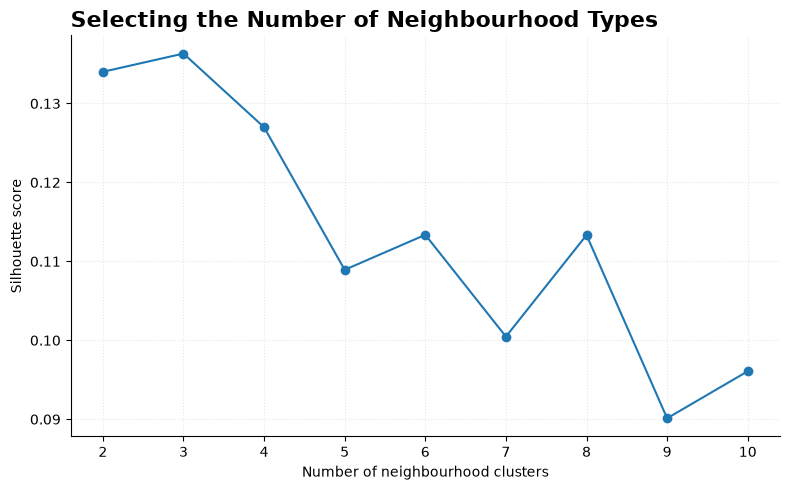

In [27]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    silhouette_df["k"],
    silhouette_df["Silhouette"],
    marker="o"
)

ax.set_xticks(
    silhouette_df["k"]
)

ax.set_xlabel(
    "Number of neighbourhood clusters"
)

ax.set_ylabel(
    "Silhouette score"
)

ax.set_title(
    "Selecting the Number of Neighbourhood Types",
    fontsize=16,
    fontweight="bold",
    loc="left"
)

ax.grid(
    linestyle=":",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [28]:
# Importantly it does not mean that there are eight actual natural neighbourhood types
# This is a descriptive analysis dependent on initial k clusters selected 
# (based on silhoutte plot it's reasonable however)
k = 8

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=50
)

# +1 so clusters are numbered 1–9 instead of 0–8
neighbourhood_cluster_labels = (
    kmeans.fit_predict(X_scaled)
    + 1
)

cluster_lookup = df_merge_all[
    [
        "NEIGHBOURHOOD_ID",
        "NEIGHBOURHOOD"
    ]
].copy()

cluster_lookup["Cluster"] = (
    neighbourhood_cluster_labels
)

In [29]:
# Variables were fed into ChatGPT to create themes of each cluster
cluster_names = {
    1: "Immigrant-Dense Neighbourhoods with Lower Recorded Health Burden",
    2: "House-Based & Youth/Health-Burdened Neighbourhoods",
    3: "Walkable, High-Turnout & Lower-Immigration Neighbourhoods",
    4: "Lower-Equity & Socioeconomically Vulnerable Neighbourhoods",
    5: "Downtown Employment & Cultural-Service Neighbourhoods",
    6: "Affluent, High-Equity & Preventive-Care Advantaged Neighbourhoods",
    7: "Social-Housing Concentrated & High Health-Burden Neighbourhoods",
    8: "High-Intensity Urban & Public-Safety Activity Neighbourhoods"
}

# Standardized data
X_standardized = pd.DataFrame(
    X_scaled,
    columns=X_neighbourhoods.columns,
    index=X_neighbourhoods.index
)

X_standardized["Cluster"] = (
    neighbourhood_cluster_labels
)


# Mean STANDARDIZED value of each variable within each cluster
cluster_profiles = (
    X_standardized
    .groupby("Cluster")
    .mean()
)


# Mean ORIGINAL value of each variable within each cluster
X_imputed_df = pd.DataFrame(
    X_imputed,
    columns=X_neighbourhoods.columns,
    index=X_neighbourhoods.index
)

X_imputed_df["Cluster"] = (
    neighbourhood_cluster_labels
)

cluster_original_means = (
    X_imputed_df
    .groupby("Cluster")
    .mean()
)


# Print top 10 defining variables for each cluster
for cluster in cluster_profiles.index:

    z_profile = (
        cluster_profiles
        .loc[cluster]
        .sort_values(
            key=abs,
            ascending=False
        )
        .head(10)
    )

    # Get descriptive cluster label
    cluster_label = cluster_names.get(
        cluster,
        "Unlabelled Cluster"
    )

    print(
        f"\n========== CLUSTER {cluster}: "
        f"{cluster_label.upper()} =========="
    )

    for variable, z in z_profile.items():

        original_mean = (
            cluster_original_means
            .loc[cluster, variable]
        )

        direction = (
            "above"
            if z > 0
            else "below"
        )

        print(
            f"{variable}: "
            f"{z:.2f} SD {direction} average "
            f"(cluster mean = {original_mean:.2f})"
        )


========== CLUSTER 1: IMMIGRANT-DENSE NEIGHBOURHOODS WITH LOWER RECORDED HEALTH BURDEN ==========
Mother Tongue English or French_df32: -1.43 SD below average (cluster mean = 0.36)
Pravelence_MentalHealthVisits_df57: -1.40 SD below average (cluster mean = 6.78)
Prevalence_Asthma_df53: -1.37 SD below average (cluster mean = 10.99)
Non-immigrant Rate_df32: -1.29 SD below average (cluster mean = 0.33)
PercentBirths_MothersNotBornInCanada_df60: 1.09 SD above average (cluster mean = 0.76)
Canadian Citizen Rate_df32: -1.05 SD below average (cluster mean = 0.77)
Indigenous Rate_df32: -1.00 SD below average (cluster mean = 0.00)
Annual_Injury_ED_VisitsYouth_df62: -0.92 SD below average (cluster mean = 9.53)
Annual_ED_MentalHealthVisits_df63: -0.91 SD below average (cluster mean = 15.03)
Premature Mortality_df48: -0.90 SD below average (cluster mean = 156.14)

========== CLUSTER 2: HOUSE-BASED & YOUTH/HEALTH-BURDENED NEIGHBOURHOODS ==========
Pravalence_COPD_df54: 1.23 SD above average (cluste

In [30]:
# Load Toronto neighbourhood polygons

neighbourhoods_map = gpd.read_file(
    "ZZ_voting/Neighbourhoods - historical 140 - 4326.geojson"
)

# Make map neighbourhood ID match df_merge_all
neighbourhoods_map["NEIGHBOURHOOD_ID"] = (
    neighbourhoods_map["AREA_SHORT_CODE"]
    .astype(int)
)


# Join clusters onto neighbourhood polygons

map_df = neighbourhoods_map.merge(
    cluster_lookup,
    on="NEIGHBOURHOOD_ID",
    how="left"
)

In [31]:
X_standardized = pd.DataFrame(
    X_scaled,
    columns=X_neighbourhoods.columns
)

X_standardized["Cluster"] = (
    neighbourhood_cluster_labels
)

cluster_profiles = (
    X_standardized
    .groupby("Cluster")
    .mean()
)

findfont: Failed to find font weight black for DejaVu Sans, now using 700.
findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


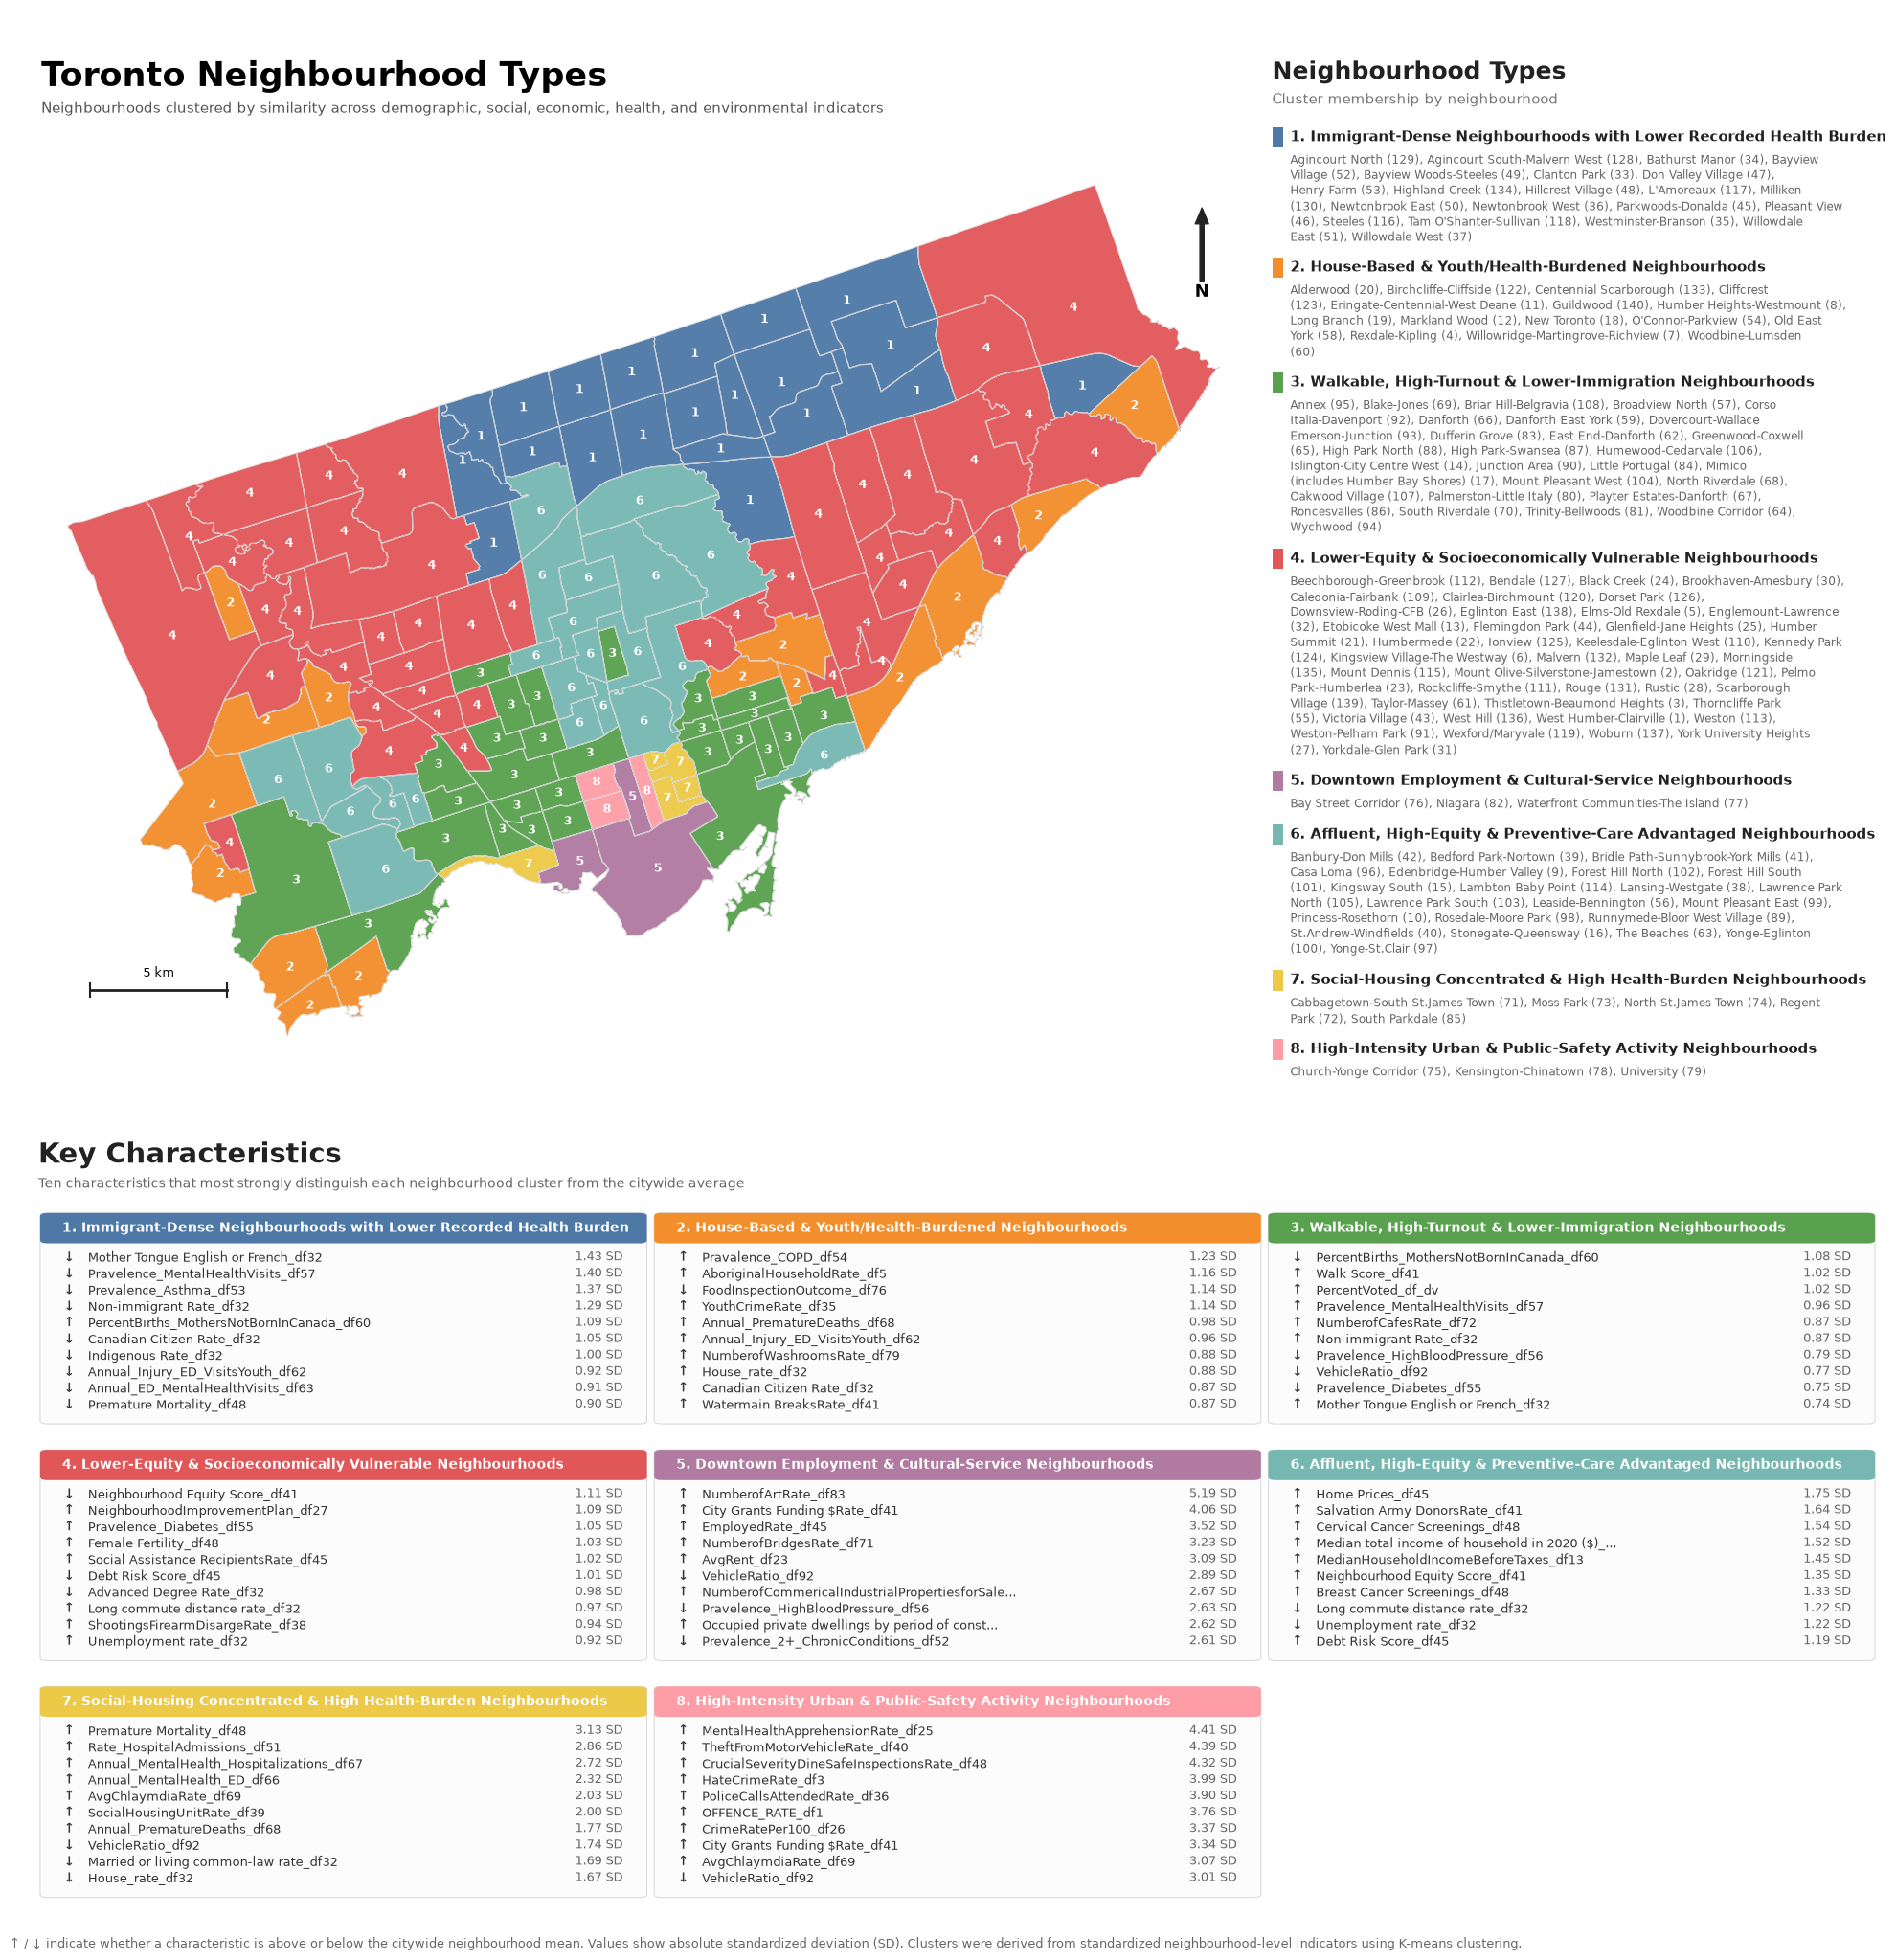

In [32]:
# CLUSTER COLORS

cluster_colors = {
    1: "#4E79A7",
    2: "#F28E2B",
    3: "#59A14F",
    4: "#E15759",
    5: "#B07AA1",
    6: "#76B7B2",
    7: "#EDC948",
    8: "#FF9DA7",
    9: "#9C755F"
}


# EASY LAYOUT CONTROLS

# Bigger number = neighbourhood section moves right
legend_x = 0.10

# Move the legend up or down
legend_y_shift = -0.03

# Character wrapping of neighbourhood names
legend_wrap_width = 72

# Width ratio:
# first number = MAP
# second number = neighbourhood description section
map_legend_width_ratio = [
    4.15,
    1.85
]

# Overall figure
figure_width = 20
figure_height = 23

# FONT SIZE CONTROLS

# Neighbourhood legend
legend_title_fs = 18
legend_subtitle_fs = 11
legend_cluster_fs = 11
legend_neighbourhood_fs = 8.5

# Characteristic cards
cards_section_title_fs = 21
cards_section_subtitle_fs = 10

card_header_fs = 10
card_variable_fs = 9
card_sd_fs = 9

# PROJECT MAP INTO METRES

map_plot = map_df.to_crs(
    "EPSG:26917"
).copy()

clusters = sorted(
    map_plot["Cluster"]
    .dropna()
    .astype(int)
    .unique()
)


# CREATE NEIGHBOURHOOD LISTS

cluster_neighbourhoods = {}

for cluster in clusters:

    names = (
        map_plot.loc[
            map_plot["Cluster"] == cluster,
            "NEIGHBOURHOOD"
        ]
        .dropna()
        .sort_values()
        .tolist()
    )

    cluster_neighbourhoods[
        cluster
    ] = names


# GET TOP 10 CHARACTERISTICS PER CLUSTER

top_characteristics = {}

for cluster in cluster_profiles.index:

    top_characteristics[
        cluster
    ] = (
        cluster_profiles
        .loc[cluster]
        .sort_values(
            key=abs,
            ascending=False
        )
        .head(10)
    )


# CREATE FIGURE

fig = plt.figure(
    figsize=(
        figure_width,
        figure_height
    ),
    facecolor="white"
)


# OVERALL VERTICAL LAYOUT

outer_gs = GridSpec(
    2,
    1,
    figure=fig,

    # Give more vertical room to map + neighbourhood list
    height_ratios=[
        2.05,
        1.25
    ],

    hspace=0.035
)


# TOP SECTION:
# BIG MAP + NEIGHBOURHOOD DESCRIPTIONS

top_gs = GridSpecFromSubplotSpec(
    1,
    2,
    subplot_spec=outer_gs[0],

    # MAP IS NOW LARGER
    width_ratios=map_legend_width_ratio,

    # Minimal gap between them
    wspace=0.005
)


ax = fig.add_subplot(
    top_gs[0]
)

legend_ax = fig.add_subplot(
    top_gs[1]
)

legend_ax.set_axis_off()


# DRAW MAP

for cluster in clusters:

    subset = map_plot[
        map_plot["Cluster"] == cluster
    ]

    subset.plot(
        ax=ax,
        color=cluster_colors[
            cluster
        ],
        edgecolor="white",
        linewidth=0.85,
        alpha=0.96
    )


# Missing neighbourhoods

missing = map_plot[
    map_plot["Cluster"].isna()
]

if len(missing) > 0:

    missing.plot(
        ax=ax,
        color="#D9D9D9",
        edgecolor="white",
        linewidth=0.8
    )


# Neighbourhood boundaries

map_plot.boundary.plot(
    ax=ax,
    color="#444444",
    linewidth=0.25,
    alpha=0.35
)

# ADD CLUSTER NUMBERS TO NEIGHBOURHOODS

label_points = map_plot.copy()

# representative_point() guarantees the point lies inside polygon
label_points["label_point"] = (
    label_points.geometry
    .representative_point()
)

for _, row in label_points.iterrows():

    if pd.notna(row["Cluster"]):

        x = row["label_point"].x
        y = row["label_point"].y

        txt = ax.text(
            x,
            y,
            str(int(row["Cluster"])),
            fontsize=9,
            fontweight="bold",
            color="#FFFFFF",
            ha="center",
            va="center",
            zorder=10
        )


# MAP TITLE

title_x = 0.025   # controls horizontal shift

ax.set_title(
    "Toronto Neighbourhood Types",
    fontsize=25,
    fontweight="bold",
    x=title_x,
    y=1.1,
    ha="left",
    pad=0
)

ax.text(
    title_x,
    1.068,
    (
        "Neighbourhoods clustered by similarity across demographic, "
        "social, economic, health, and environmental indicators"
    ),
    transform=ax.transAxes,
    fontsize=10.5,
    color="#555555",
    va="bottom",
    ha="left"
)

# NORTH ARROW

ax.annotate(
    "N",
    xy=(0.94, 0.97),
    xytext=(0.94, 0.88),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    arrowprops=dict(
        facecolor="#222222",
        edgecolor="#222222",
        width=3,
        headwidth=10,
        headlength=12
    )
)


# SCALE BAR

xmin, ymin, xmax, ymax = (
    map_plot.total_bounds
)

map_width = (
    xmax - xmin
)

map_height = (
    ymax - ymin
)

scale_length = 5000

scale_x = (
    xmin
    + map_width * 0.02
)

scale_y = (
    ymin
    + map_height * 0.055
)


# Main scale line
ax.plot(
    [
        scale_x,
        scale_x + scale_length
    ],
    [
        scale_y,
        scale_y
    ],
    color="#222222",
    linewidth=2
)


# Scale ticks
tick_height = (
    map_height * 0.008
)

for x in [
    scale_x,
    scale_x + scale_length
]:

    ax.plot(
        [x, x],
        [
            scale_y - tick_height,
            scale_y + tick_height
        ],
        color="#222222",
        linewidth=1.5
    )


# Scale label
ax.text(
    scale_x + scale_length / 2,
    scale_y + map_height * 0.012,
    "5 km",
    ha="center",
    va="bottom",
    fontsize=9
)


ax.set_axis_off()
ax.set_aspect("equal")

# MOVE MAP CONTENT UP WITHOUT MOVING TITLE / SUBTITLE

current_ymin, current_ymax = ax.get_ylim()

map_shift_up = 0.04   # proportion of map height

y_range = current_ymax - current_ymin
shift = y_range * map_shift_up

ax.set_ylim(
    current_ymin - shift,
    current_ymax - shift
)


# NEIGHBOURHOOD TYPES SECTION

# Everything below uses legend_x so the entire block
# can be shifted right with ONE variable.


legend_ax.text(
    legend_x,
    0.990 + legend_y_shift,
    "Neighbourhood Types",
    transform=legend_ax.transAxes,
    fontsize=legend_title_fs,
    fontweight="bold",
    color="#222222",
    va="top",
    ha="left"
)

legend_ax.text(
    legend_x,
    0.965 + legend_y_shift,
    "Cluster membership by neighbourhood",
    transform=legend_ax.transAxes,
    fontsize=legend_subtitle_fs,
    color="#777777",
    va="top",
    ha="left"
)


# NEIGHBOURHOOD LISTS

# Start close to heading
y = 0.930 + legend_y_shift


for cluster in clusters:

    # COLOR SQUARE

    legend_ax.add_patch(
        Rectangle(
            (
                legend_x,
                y - 0.008
            ),
            0.020,
            0.016,
            transform=legend_ax.transAxes,
            facecolor=cluster_colors[
                cluster
            ],
            edgecolor="none"
        )
    )


    # CLUSTER NAME

    text_x = (
        legend_x + 0.032
    )

    legend_ax.text(
        text_x,
        y,
        f"{cluster}. {cluster_names[cluster]}",
        transform=legend_ax.transAxes,
        fontsize=legend_cluster_fs,
        fontweight="bold",
        color="#222222",
        va="center",
        ha="left"
    )


    # NEIGHBOURHOOD NAMES

    names_text = ", ".join(
        cluster_neighbourhoods[
            cluster
        ]
    )

    neighbourhood_wrap_width = 90

    wrapped_names = textwrap.fill(
        names_text,
        width=neighbourhood_wrap_width,
        break_long_words=False,
        break_on_hyphens=False
    )


    y_names = (
        y - 0.012
    )


    legend_ax.text(
        text_x,
        y_names,
        wrapped_names,
        transform=legend_ax.transAxes,
        fontsize=legend_neighbourhood_fs,
        color="#666666",
        va="top",
        ha="left",
        linespacing=1.35
    )


    # CALCULATE HEIGHT OF THIS CLUSTER

    n_lines = len(
        wrapped_names.split("\n")
    )


    # Much tighter spacing between clusters
    y -= (
        0.030
        + n_lines * 0.012
    )


# BOTTOM:
# KEY CHARACTERISTICS

key_ax = fig.add_subplot(
    outer_gs[1]
)

key_ax.set_axis_off()


# Section title

key_ax.text(
    0.00,
    0.985,
    "Key Characteristics",
    transform=key_ax.transAxes,
    fontsize=cards_section_title_fs,
    fontweight="bold",
    va="bottom",
    color="#222222"
)


key_ax.text(
    0.00,
    0.975,
    (
        "Ten characteristics that most strongly distinguish each "
        "neighbourhood cluster from the citywide average"
    ),
    transform=key_ax.transAxes,
    fontsize=cards_section_subtitle_fs,
    color="#666666",
    va="top"
)


# CARD GRID

ncols = 3
nrows = 3

left_margin = 0.005
right_margin = 0.005

# Very small gaps
hgap = 0.012
vgap = 0.012

grid_top = 0.925
grid_bottom = 0.025

usable_width = (
    1
    - left_margin
    - right_margin
)

usable_height = (
    grid_top
    - grid_bottom
)

box_w = (
    usable_width
    - hgap * (ncols - 1)
) / ncols

# CARD STYLE / LAYOUT CONTROLS

# Vertical spacing between characteristic rows
characteristic_spacing = 0.021

# Card height relative to available row height
card_height_scale = 0.90

row_h = (
    usable_height
    - vgap * (nrows - 1)
) / nrows

box_h = (
    row_h
    * card_height_scale
)

# DRAW CARDS

for idx, cluster in enumerate(
    clusters
):

    row = (
        idx // ncols
    )

    col = (
        idx % ncols
    )


    x0 = (
        left_margin
        + col * (
            box_w + hgap
        )
    )


    y_top = (
        grid_top
        - row * (row_h + vgap)
    )


    y0 = (
        y_top
        - box_h
    )


    # CARD BACKGROUND

    card = FancyBboxPatch(
        (
            x0,
            y0
        ),
        box_w,
        box_h,
        boxstyle=(
            "round,pad=0.004,"
            "rounding_size=0.004"
        ),
        linewidth=0.7,
        edgecolor="#D6D6D6",
        facecolor="#FCFCFC",
        transform=key_ax.transAxes,
        clip_on=False
    )

    key_ax.add_patch(
        card
    )


    # COMPACT HEADER

    header_h = 0.031


    header = FancyBboxPatch(
        (
            x0,
            y_top - header_h
        ),
        box_w,
        header_h,
        boxstyle=(
            "round,pad=0.004,"
            "rounding_size=0.004"
        ),
        linewidth=0,
        facecolor=cluster_colors[
            cluster
        ],
        transform=key_ax.transAxes,
        clip_on=False
    )

    key_ax.add_patch(
        header
    )


    # Header text

    key_ax.text(
        x0 + 0.008,
        y_top - header_h / 2,
        f"{cluster}. {cluster_names[cluster]}",
        transform=key_ax.transAxes,
        fontsize=card_header_fs,
        fontweight="bold",
        color="white",
        va="center",
        ha="left"
    )


    # TOP 10 CHARACTERISTICS

    char_y = (
        y_top
        - header_h
        - 0.014
    )


    profile = (
        top_characteristics[
            cluster
        ]
    )


    for variable, z in (
        profile.items()
    ):

        direction_symbol = (
            "↑"
            if z > 0
            else "↓"
        )


        # Shorten exceptionally long variable names
        if len(variable) > 48:

            variable = (
                variable[:45]
                + "..."
            )


        # Variable label

        # Arrow only
        key_ax.text(
            x0 + 0.009,
            char_y,
            direction_symbol,
            transform=key_ax.transAxes,
            fontsize=card_variable_fs,
            fontweight="black",   # only arrow is thick
            color="#333333",
            va="top",
            ha="left"
        )

        # Variable text
        key_ax.text(
            x0 + 0.022,
            char_y,
            variable,
            transform=key_ax.transAxes,
            fontsize=card_variable_fs,
            fontweight="normal",
            color="#333333",
            va="top",
            ha="left"
        )


        # SD

        key_ax.text(
            x0 + box_w - 0.009,
            char_y,
            f"{abs(z):.2f} SD",
            transform=key_ax.transAxes,
            fontsize=card_sd_fs,
            color="#666666",
            va="top",
            ha="right",
            fontweight="medium"
        )


        # Tight characteristic spacing
        char_y -= characteristic_spacing


# FOOTNOTE

fig.text(
    0.025,
    0.10,
    (
        "↑ / ↓ indicate whether a characteristic is above or below "
        "the citywide neighbourhood mean. Values show absolute "
        "standardized deviation (SD). Clusters were derived from "
        "standardized neighbourhood-level indicators using K-means clustering."
    ),
    fontsize=9,
    color="#666666",
    ha="left"
)


# FINAL LAYOUT

plt.subplots_adjust(
    left=0.025,
    right=0.985,
    top=0.980,
    bottom=0.030
)

# MOVE ENTIRE KEY CHARACTERISTICS SECTION

key_pos = key_ax.get_position()

key_shift_up = 0.075
key_shift_right = 0.015

key_ax.set_position([
    key_pos.x0 + key_shift_right,
    key_pos.y0 + key_shift_up,
    key_pos.width,
    key_pos.height
])

# MOVE ENTIRE LEGEND SECTION LEFT
# ============================================================

legend_pos = legend_ax.get_position()

legend_shift_left = 0.035

legend_ax.set_position([
    legend_pos.x0 - legend_shift_left,
    legend_pos.y0,
    legend_pos.width,
    legend_pos.height
])

plt.show()